# EDA: Teleoperation Dataset (Single Cube, 30 Episodes)

Exploratory data analysis of the raw teleop recordings before action computation and training.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import zarr
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

# Load all zarr stores, skip empty ones
zarr_dir = Path("datasets/raw/single_cube/teleop")
zarr_paths = sorted(zarr_dir.rglob("*.zarr"))

data_arrays = {}
all_ep_ends = []
offset = 0

for zp in zarr_paths:
    root = zarr.open_group(str(zp), mode="r")
    ep_ends = np.asarray(root["meta"]["episode_ends"])
    if ep_ends.size == 0:
        continue
    n_steps = int(ep_ends[-1])
    all_ep_ends.append(ep_ends + offset)
    for key in root["data"]:
        arr = np.asarray(root["data"][key][:n_steps])
        data_arrays.setdefault(key, []).append(arr)
    offset += n_steps

# Concatenate
for key in data_arrays:
    data_arrays[key] = np.concatenate(data_arrays[key], axis=0)
episode_ends = np.concatenate(all_ep_ends)
episode_starts = np.concatenate([[0], episode_ends[:-1]])

print(f"Total episodes: {episode_ends.size}")
print(f"Total timesteps: {offset}")
print(f"\nData keys and shapes:")
for key in sorted(data_arrays):
    print(f"  {key}: {data_arrays[key].shape} ({data_arrays[key].dtype})")

/Users/shyngys/ethz/robot_learning/ethz-course-2026/hw3_imitation_learning/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


Total episodes: 30
Total timesteps: 28567

Data keys and shapes:
  action_gripper: (28567, 1) (float32)
  state_cube: (28567, 7) (float32)
  state_ee: (28567, 7) (float32)
  state_gripper: (28567, 1) (float32)
  state_joints: (28567, 6) (float32)
  state_obstacle: (28567, 3) (float32)


## 1. Episode Length Distribution

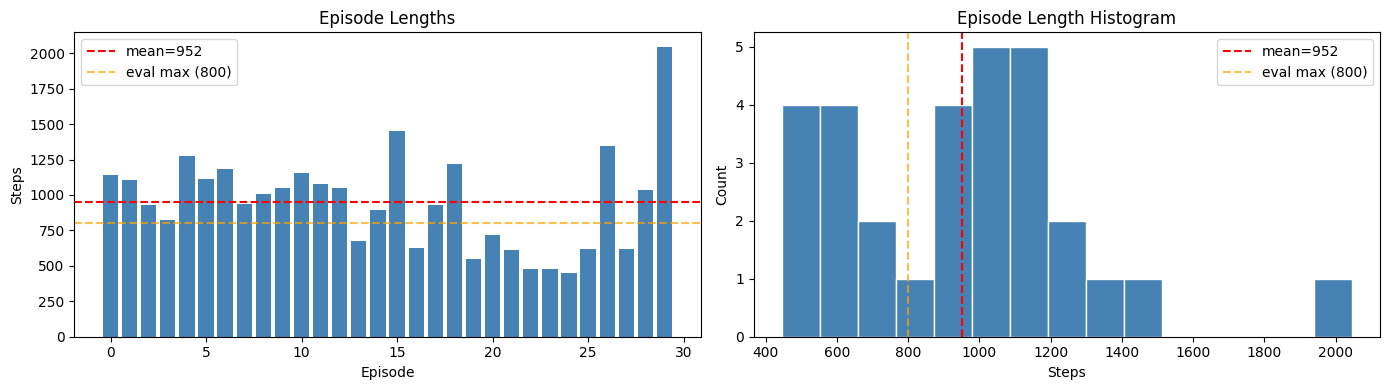

Episode length stats: min=446, max=2045, mean=952.2, std=339.5
Episodes exceeding 800 steps (eval limit): 20/30


In [12]:
ep_lengths = np.diff(np.concatenate([[0], episode_ends]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(ep_lengths)), ep_lengths, color="steelblue")
axes[0].axhline(ep_lengths.mean(), color="red", ls="--", label=f"mean={ep_lengths.mean():.0f}")
axes[0].axhline(800, color="orange", ls="--", alpha=0.7, label="eval max (800)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Steps")
axes[0].set_title("Episode Lengths")
axes[0].legend()

axes[1].hist(ep_lengths, bins=15, color="steelblue", edgecolor="white")
axes[1].axvline(ep_lengths.mean(), color="red", ls="--", label=f"mean={ep_lengths.mean():.0f}")
axes[1].axvline(800, color="orange", ls="--", alpha=0.7, label="eval max (800)")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Count")
axes[1].set_title("Episode Length Histogram")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Episode length stats: min={ep_lengths.min()}, max={ep_lengths.max()}, "
      f"mean={ep_lengths.mean():.1f}, std={ep_lengths.std():.1f}")
print(f"Episodes exceeding 800 steps (eval limit): {(ep_lengths > 800).sum()}/{len(ep_lengths)}")

## 2. End-Effector Trajectories (XYZ)

3D position of the end-effector over time. Each episode is a separate color.

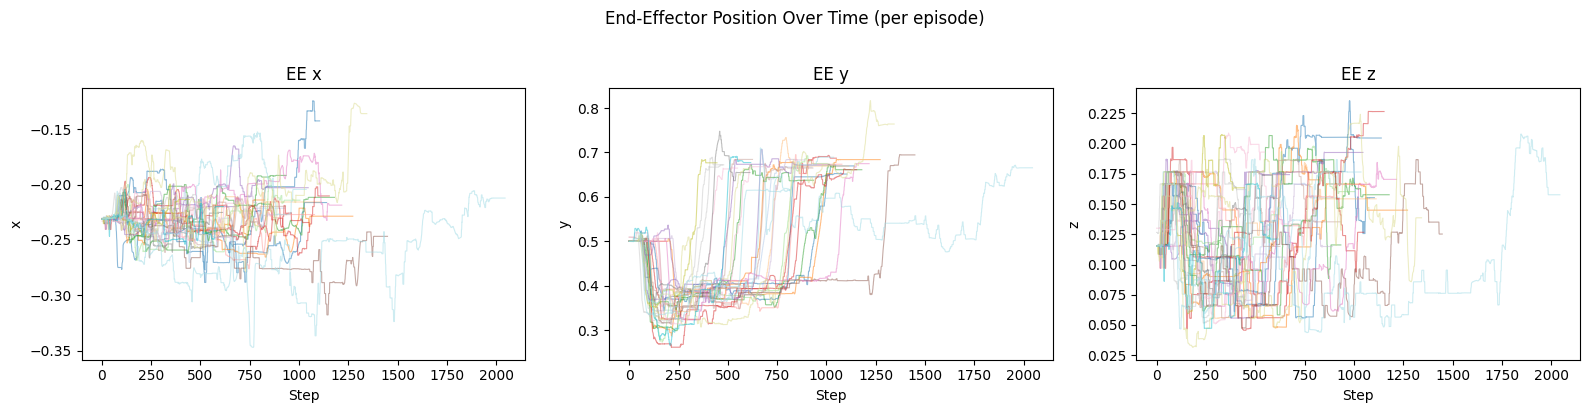

In [13]:
ee = data_arrays["state_ee"]  # (N, 7): x, y, z, qw, qx, qy, qz
labels = ["x", "y", "z"]
colors = plt.cm.tab20(np.linspace(0, 1, len(episode_ends)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for dim, (ax, label) in enumerate(zip(axes, labels)):
    for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
        t = np.arange(e - s)
        ax.plot(t, ee[s:e, dim], alpha=0.5, lw=0.8, color=colors[i])
    ax.set_xlabel("Step")
    ax.set_ylabel(label)
    ax.set_title(f"EE {label}")
plt.suptitle("End-Effector Position Over Time (per episode)", y=1.02)
plt.tight_layout()
plt.show()

## 3. EE Trajectories in 2D (Top-down XY) and Side View (XZ)

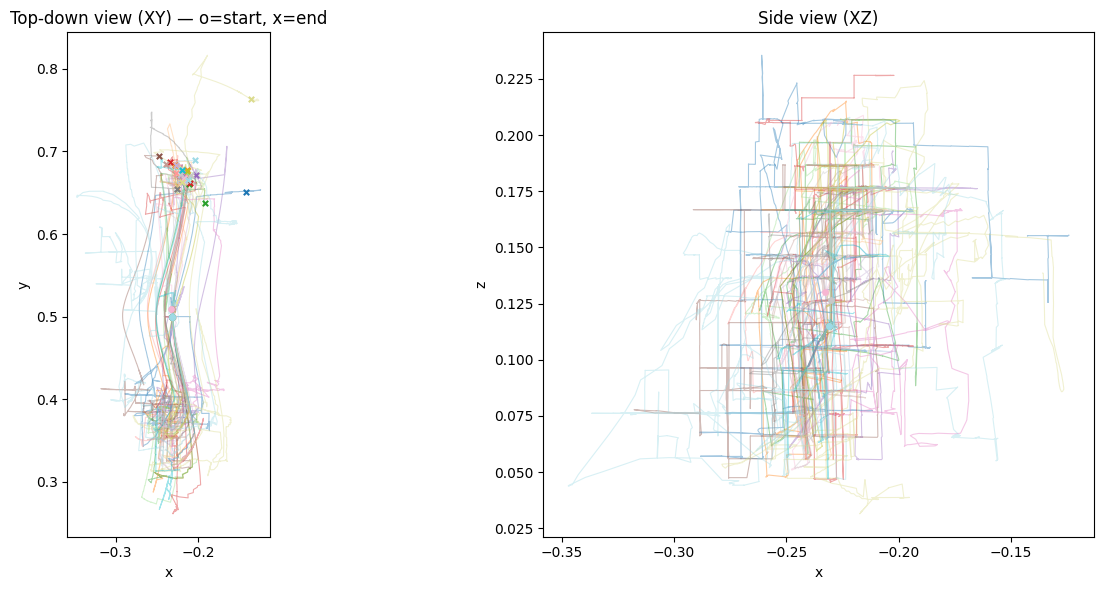

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    axes[0].plot(ee[s:e, 0], ee[s:e, 1], alpha=0.4, lw=0.8, color=colors[i])
    axes[0].scatter(ee[s, 0], ee[s, 1], marker="o", s=15, color=colors[i], zorder=5)
    axes[0].scatter(ee[e-1, 0], ee[e-1, 1], marker="x", s=15, color=colors[i], zorder=5)

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Top-down view (XY) — o=start, x=end")
axes[0].set_aspect("equal")

for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    axes[1].plot(ee[s:e, 0], ee[s:e, 2], alpha=0.4, lw=0.8, color=colors[i])
    axes[1].scatter(ee[s, 0], ee[s, 2], marker="o", s=15, color=colors[i], zorder=5)

axes[1].set_xlabel("x")
axes[1].set_ylabel("z")
axes[1].set_title("Side view (XZ)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## 4. Cube Position Over Time

Cube XYZ position — useful to check if all episodes successfully picked up and placed the cube.

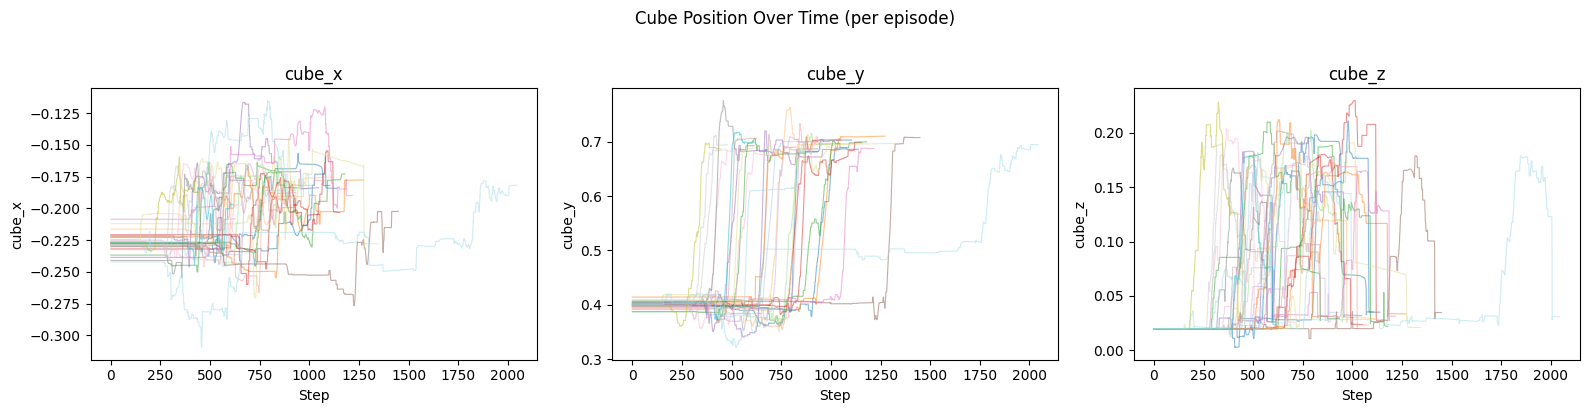

Final cube z: min=0.0210, max=0.0354, mean=0.0291
Episodes with cube z < 0.04 (in bin): 30/30


In [15]:
cube = data_arrays["state_cube"]  # (N, 7): pos(3) + quat(4)
labels_cube = ["cube_x", "cube_y", "cube_z"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for dim, (ax, label) in enumerate(zip(axes, labels_cube)):
    for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
        t = np.arange(e - s)
        ax.plot(t, cube[s:e, dim], alpha=0.5, lw=0.8, color=colors[i])
    ax.set_xlabel("Step")
    ax.set_ylabel(label)
    ax.set_title(label)
plt.suptitle("Cube Position Over Time (per episode)", y=1.02)
plt.tight_layout()
plt.show()

# Check final cube z position per episode (should be low = in bin)
final_z = np.array([cube[e-1, 2] for e in episode_ends])
print(f"Final cube z: min={final_z.min():.4f}, max={final_z.max():.4f}, mean={final_z.mean():.4f}")
print(f"Episodes with cube z < 0.04 (in bin): {(final_z < 0.04).sum()}/{len(final_z)}")

## 5. Gripper Actions

Check the gripper control commands — should show open/close patterns during grasping.

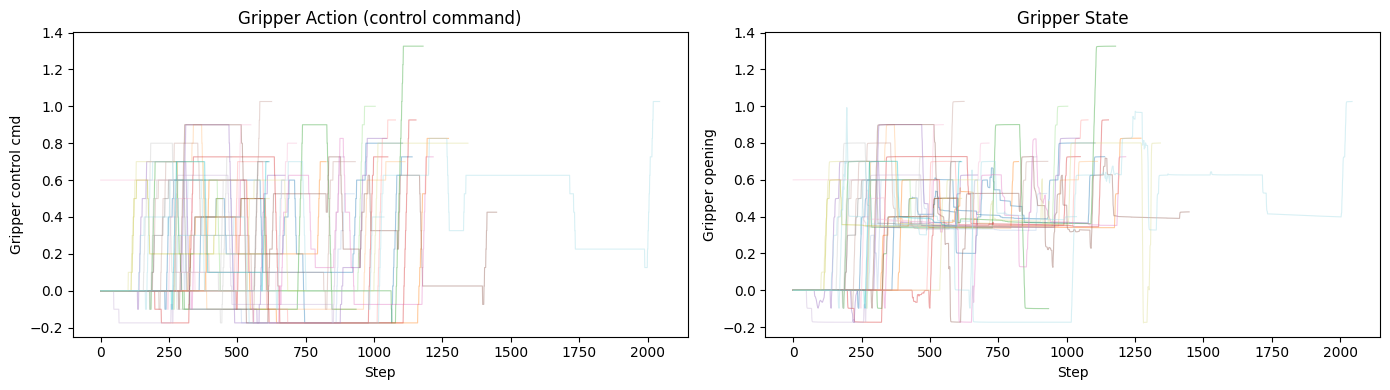

Gripper action range: [-0.1740, 1.3260]
Gripper state range:  [-0.1776, 1.3258]


In [16]:
gripper_action = data_arrays["action_gripper"].squeeze()
gripper_state = data_arrays["state_gripper"].squeeze()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    t = np.arange(e - s)
    axes[0].plot(t, gripper_action[s:e], alpha=0.4, lw=0.8, color=colors[i])
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Gripper control cmd")
axes[0].set_title("Gripper Action (control command)")

for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    t = np.arange(e - s)
    axes[1].plot(t, gripper_state[s:e], alpha=0.4, lw=0.8, color=colors[i])
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Gripper opening")
axes[1].set_title("Gripper State")

plt.tight_layout()
plt.show()

print(f"Gripper action range: [{gripper_action.min():.4f}, {gripper_action.max():.4f}]")
print(f"Gripper state range:  [{gripper_state.min():.4f}, {gripper_state.max():.4f}]")

## 6. Obstacle Positions

Check the obstacle distribution across episodes. For ex2 (DAgger), the adversarial eval shifts this distribution.

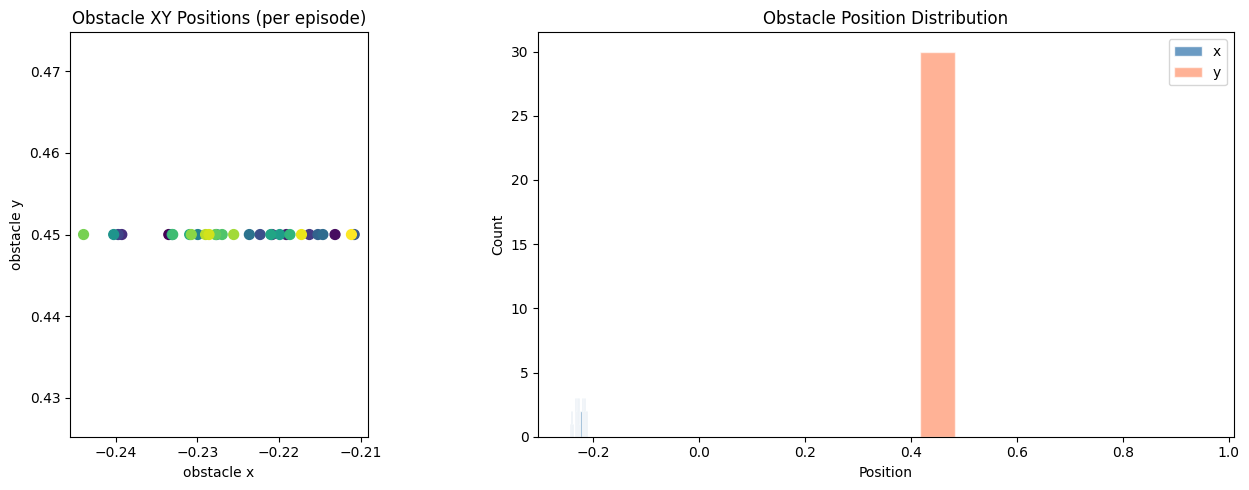

Obstacle x range: [-0.2439, -0.2108]
Obstacle y range: [0.4500, 0.4500]
Obstacle z range: [0.0600, 0.0600]


In [17]:
obstacle = data_arrays["state_obstacle"]  # (N, 3)

# Obstacle is fixed per episode — get initial position per episode
obs_per_ep = np.array([obstacle[s, :] for s in episode_starts])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter of obstacle XY positions
axes[0].scatter(obs_per_ep[:, 0], obs_per_ep[:, 1], c=range(len(obs_per_ep)), cmap="viridis", s=50)
axes[0].set_xlabel("obstacle x")
axes[0].set_ylabel("obstacle y")
axes[0].set_title("Obstacle XY Positions (per episode)")
axes[0].set_aspect("equal")

# Histogram of obstacle x
axes[1].hist(obs_per_ep[:, 0], bins=15, color="steelblue", edgecolor="white", alpha=0.8, label="x")
axes[1].hist(obs_per_ep[:, 1], bins=15, color="coral", edgecolor="white", alpha=0.6, label="y")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Count")
axes[1].set_title("Obstacle Position Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Obstacle x range: [{obs_per_ep[:, 0].min():.4f}, {obs_per_ep[:, 0].max():.4f}]")
print(f"Obstacle y range: [{obs_per_ep[:, 1].min():.4f}, {obs_per_ep[:, 1].max():.4f}]")
print(f"Obstacle z range: [{obs_per_ep[:, 2].min():.4f}, {obs_per_ep[:, 2].max():.4f}]")

## 7. Delta Actions (EE XYZ)

Preview what the computed actions will look like — the deltas between consecutive EE positions. Large spikes may indicate teleop pauses or jerky motion.

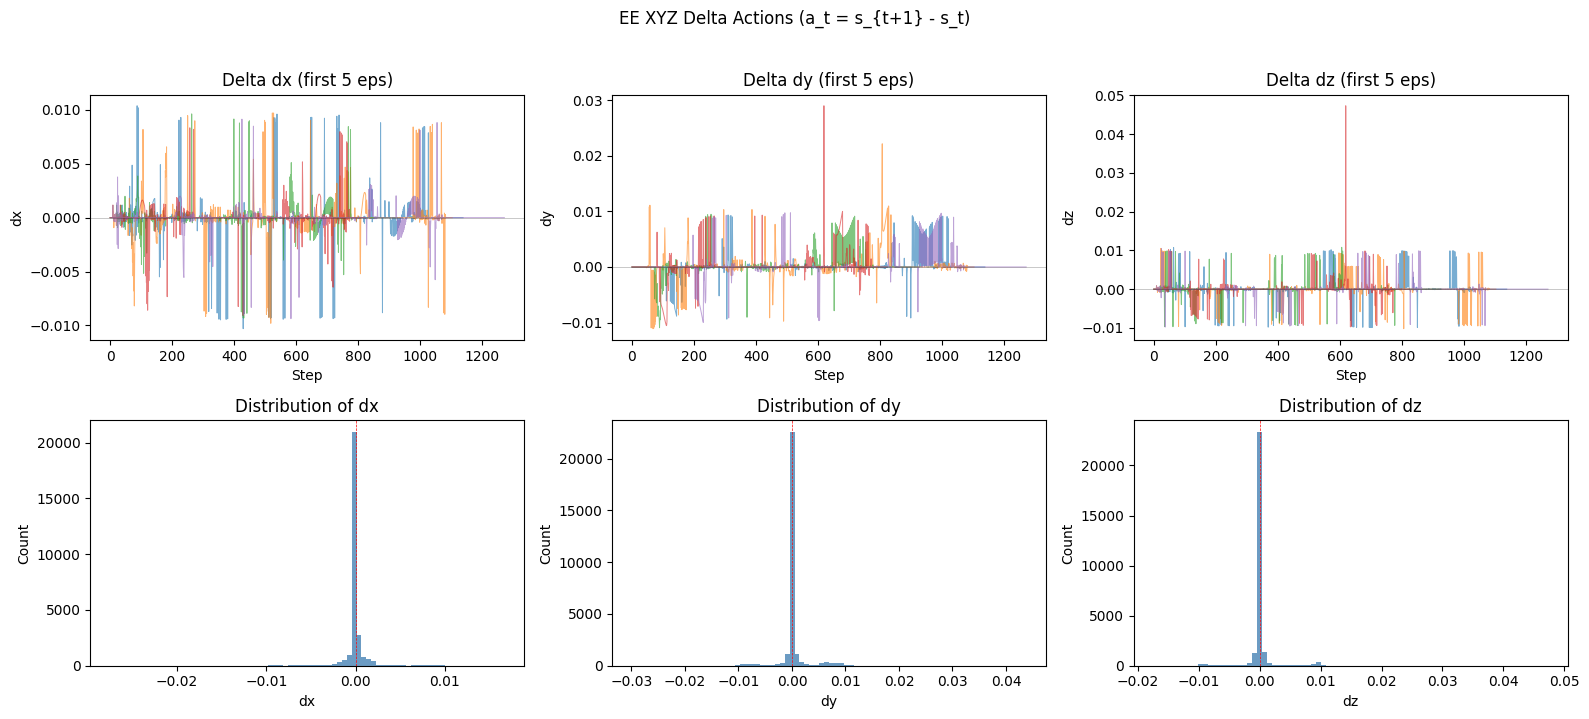

Near-zero deltas (||delta|| < 1e-05): 13078/28537 (45.8%)
Delta magnitude: mean=0.001635, std=0.003160, max=0.055577


In [18]:
ee_xyz = ee[:, :3]
labels_d = ["dx", "dy", "dz"]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for dim, label in enumerate(labels_d):
    # Time series (first 5 episodes)
    for i, (s, e) in enumerate(zip(episode_starts[:5], episode_ends[:5])):
        deltas = ee_xyz[s+1:e, dim] - ee_xyz[s:e-1, dim]
        axes[0, dim].plot(np.arange(len(deltas)), deltas, alpha=0.6, lw=0.7, label=f"ep{i}")
    axes[0, dim].set_xlabel("Step")
    axes[0, dim].set_ylabel(label)
    axes[0, dim].set_title(f"Delta {label} (first 5 eps)")
    axes[0, dim].axhline(0, color="k", lw=0.5, alpha=0.3)

    # Histogram over all episodes
    all_deltas = []
    for s, e in zip(episode_starts, episode_ends):
        all_deltas.append(ee_xyz[s+1:e, dim] - ee_xyz[s:e-1, dim])
    all_deltas = np.concatenate(all_deltas)
    axes[1, dim].hist(all_deltas, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
    axes[1, dim].set_xlabel(label)
    axes[1, dim].set_ylabel("Count")
    axes[1, dim].set_title(f"Distribution of {label}")
    axes[1, dim].axvline(0, color="red", lw=0.5, ls="--")

plt.suptitle("EE XYZ Delta Actions (a_t = s_{t+1} - s_t)", y=1.02)
plt.tight_layout()
plt.show()

# Fraction of near-zero deltas (idle time indicator)
all_d = []
for s, e in zip(episode_starts, episode_ends):
    all_d.append(np.linalg.norm(ee_xyz[s+1:e] - ee_xyz[s:e-1], axis=1))
all_d = np.concatenate(all_d)
idle_thresh = 1e-5
print(f"Near-zero deltas (||delta|| < {idle_thresh}): {(all_d < idle_thresh).sum()}/{len(all_d)} "
      f"({100*(all_d < idle_thresh).mean():.1f}%)")
print(f"Delta magnitude: mean={all_d.mean():.6f}, std={all_d.std():.6f}, max={all_d.max():.6f}")

## 8. Joint Angles Over Time

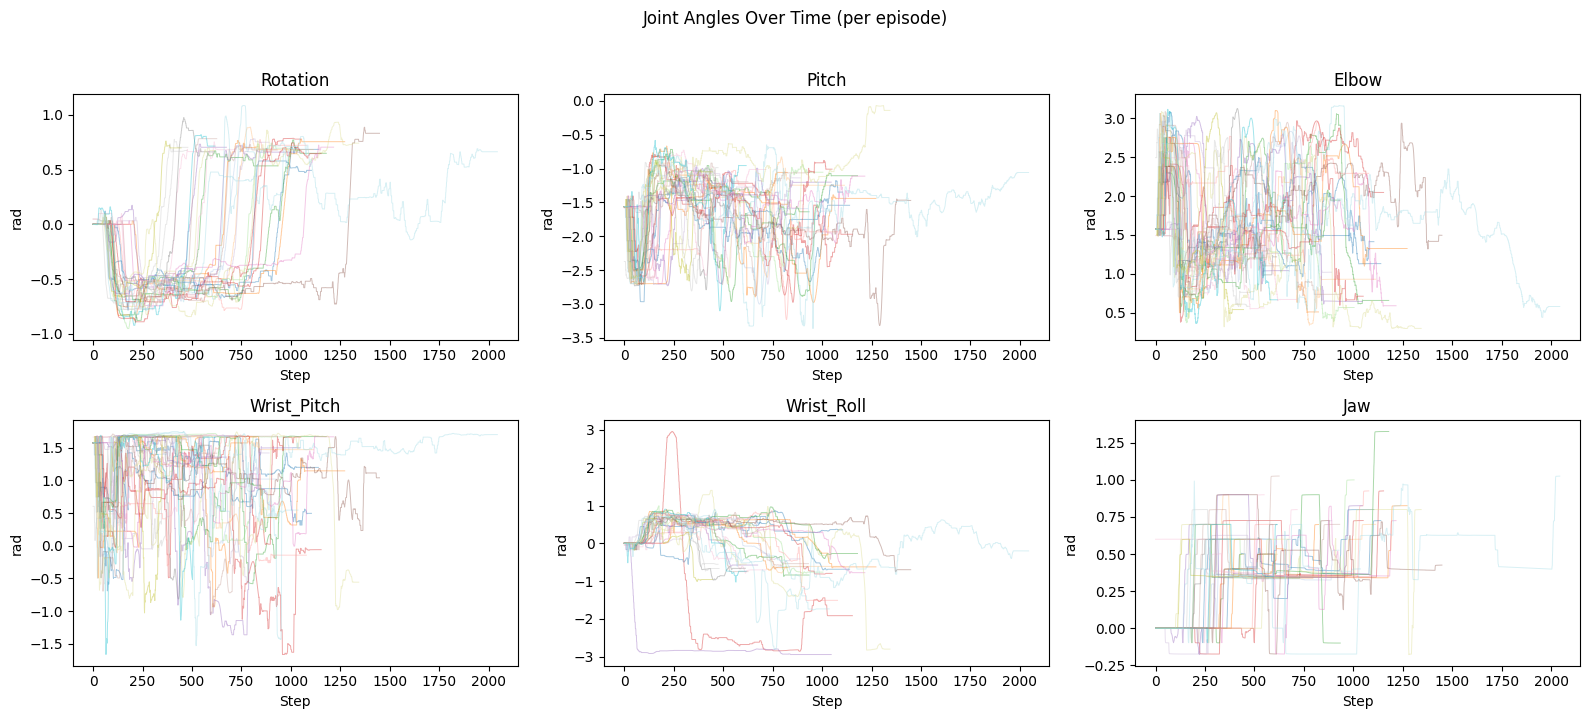

In [19]:
joints = data_arrays["state_joints"]  # (N, 6)
joint_names = ["Rotation", "Pitch", "Elbow", "Wrist_Pitch", "Wrist_Roll", "Jaw"]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()
for dim in range(6):
    ax = axes[dim]
    for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
        t = np.arange(e - s)
        ax.plot(t, joints[s:e, dim], alpha=0.4, lw=0.7, color=colors[i])
    ax.set_xlabel("Step")
    ax.set_ylabel("rad")
    ax.set_title(joint_names[dim])

plt.suptitle("Joint Angles Over Time (per episode)", y=1.02)
plt.tight_layout()
plt.show()

## 9. State Value Ranges Summary

Overview of min/max/mean/std for all state arrays — helpful for sanity checking normalization.

In [20]:
print(f"{'Key':<20} {'Shape':<18} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 80)
for key in sorted(data_arrays):
    arr = data_arrays[key]
    print(f"{key:<20} {str(arr.shape):<18} {arr.min():>10.4f} {arr.max():>10.4f} "
          f"{arr.mean():>10.4f} {arr.std():>10.4f}")

Key                  Shape                     Min        Max       Mean        Std
--------------------------------------------------------------------------------
action_gripper       (28567, 1)            -0.1740     1.3260     0.1827     0.3243
state_cube           (28567, 7)            -0.9840     1.0000     0.1417     0.4054
state_ee             (28567, 7)            -0.6247     0.9433     0.2418     0.3583
state_gripper        (28567, 1)            -0.1776     1.3258     0.3284     0.2725
state_joints         (28567, 6)            -3.3627     3.1661     0.2011     1.1971
state_obstacle       (28567, 3)            -0.2439     0.4500     0.0950     0.2767


## 10. Per-Episode Feature Correlations

Correlation between EE position, cube position, and gripper — helps verify data quality.

/Users/shyngys/ethz/robot_learning/ethz-course-2026/hw3_imitation_learning/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/shyngys/ethz/robot_learning/ethz-course-2026/hw3_imitation_learning/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


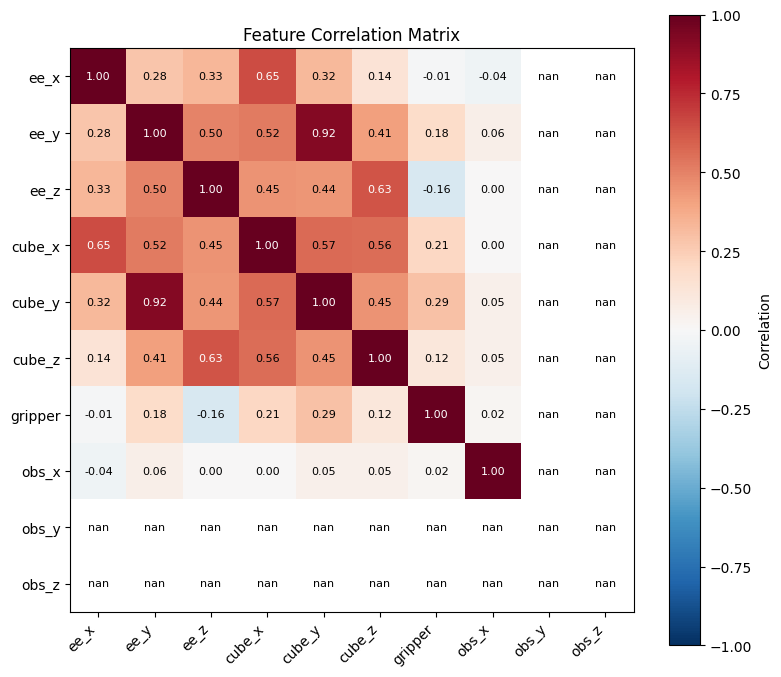

In [21]:
# Build a combined feature matrix for correlation
feature_names = ["ee_x", "ee_y", "ee_z", "cube_x", "cube_y", "cube_z", "gripper", "obs_x", "obs_y", "obs_z"]
features = np.column_stack([
    ee[:, :3],
    cube[:, :3],
    gripper_state,
    obstacle,
])

corr = np.corrcoef(features.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha="right")
ax.set_yticklabels(feature_names)
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr[i, j]) > 0.6 else "black")
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()